In [1]:
from src.utils import get_data_env
from src.dataloading import EpiConfig, DataOrchestrator, GraphDataLoaderManager, ShallowDataLoaderManager
from src.models import PersistenceModel, ClimateologyModel, NodeRFModel, NodeLSTMModel, GATv2Model

disease_name    = 'measles'
nuts_level      = 'nuts3'
min_date        = '2006-05-15'
max_date        = '2020-06-01'
split_trainval  = '2017-06-01'
split_valtest   = '2018-06-01'
split_berlin    = False

horizon_size    = 1
horizon_leadtime= 1
sequence_length = 1
lag_num         = 1

config1 = EpiConfig(
    disease             = disease_name,
    data_env_dir        = get_data_env(),
    date_range          = (min_date, max_date),
    horizon_size        = horizon_size,
    sequence_length     = sequence_length,
    horizon_leadtime    = horizon_leadtime,
    lag_num             = lag_num,
    nuts_level          = nuts_level,
    # log_transform       = ['incidence','population_size'],
    split_berlin        = split_berlin,
    include_population  = False,
    split_trainval      = split_trainval, 
    split_valtest       = split_valtest,
    target_column       = 'incidence',
    lag_column          = 'incidence',  
    verbose             = 0  
    )    

config2 = EpiConfig(
    disease             = disease_name,
    data_env_dir        = get_data_env(),
    date_range          = (min_date, max_date),
    horizon_size        = horizon_size,
    sequence_length     = sequence_length,
    horizon_leadtime    = horizon_leadtime,
    lag_num             = lag_num,
    nuts_level          = nuts_level,
    # log_transform       = ['incidence','population_size'],
    split_berlin        = split_berlin,
    include_population  = False,
    split_trainval      = split_trainval, 
    split_valtest       = split_valtest,
    target_column       = 'cases',
    lag_column          = 'incidence',  
    verbose             = 0  
    )   

config3 = EpiConfig(
    disease             = disease_name,
    data_env_dir        = get_data_env(),
    date_range          = (min_date, max_date),
    horizon_size        = horizon_size,
    sequence_length     = sequence_length,
    horizon_leadtime    = horizon_leadtime,
    lag_num             = lag_num,
    nuts_level          = nuts_level,
    # log_transform       = ['incidence','population_size'],
    split_berlin        = split_berlin,
    include_population  = False,
    split_trainval      = split_trainval, 
    split_valtest       = split_valtest,
    target_column       = 'cases',
    lag_column          = 'incidence',  
    verbose             = 0 ,
    prediction_mode     = 'classification'
    )   

data_orchestrator1 = DataOrchestrator(config1).build()
data_orchestrator2 = DataOrchestrator(config2).build()
data_orchestrator3 = DataOrchestrator(config3).build()

/home/de-schrijvers/.conda/envs/gnenv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/de-schrijvers/.conda/envs/gnenv/lib/python3.11/site-packages/pyogrio/raw.py:198: RuntimeWarning: /local/job_23330068/wissdaten/ZKI-PH4/deschrijvers_wissdaten/data/processed/germany/geospatial/shapefiles/shape_nuts3.shp contains polygon(s) with rings with invalid winding order. Autocorrecting them, but that shapefile should be corrected using ogr2ogr for example.
  return ogr_read(
/home/de-schrijvers/.conda/envs/gnenv/lib/python3.11/site-packages/pyogrio/raw.py:198: RuntimeWarning: /local/job_23330068/wissdaten/ZKI-PH4/deschrijvers_wissdaten/data/processed/germany/geospatial/shapefiles/shape_nuts3.shp contains polygon(s) with rings with invalid winding order. Autocorrecting them, but that shapefile should be corr

## Initially: predicting measles incidence

In [6]:
global_hparams = {
    "lr"                : 0.00005,
    "n_epochs"          : 100,
    "scheduler"         : 'plateau',
    "scheduler_kwargs"  : {'mode': 'min', 'factor': 0.75, 'patience': 6, 'min_lr': 1e-8},
    'min_delta'         : 0,
    'loss'              : 'outbreakweighted',
    'loss_kwargs'       : {'outbreak_threshold': 0 , 'outbreak_weight': 5},
    'patience'          : 20,
    }

shallowdata         = ShallowDataLoaderManager(data_orchestrator1).construct_dataloaders()
graphdataloader_id  = GraphDataLoaderManager(data_orchestrator1).retrieve_static_graph('identity_graph').construct_dataloaders()
graphdataloader_bn  = GraphDataLoaderManager(data_orchestrator1).retrieve_static_graph('geographical_neighbors1').construct_dataloaders()
graphdataloader_cm2 = GraphDataLoaderManager(data_orchestrator1).retrieve_static_graph('static_commuter24_1').construct_dataloaders()

spatiotemporal_model1 = GATv2Model(graphdataloader_id, name = 'GATv2 identity_graph')
spatiotemporal_model1.set_model_hparams()
spatiotemporal_model1.set_global_hparams(**global_hparams)
spatiotemporal_model1.train()
spatiotemporal_model1.forecast('test')

spatiotemporal_model2 = GATv2Model(graphdataloader_bn, name = 'GATv2 boolean neighbors')
spatiotemporal_model2.set_model_hparams()
spatiotemporal_model2.set_global_hparams(**global_hparams)
spatiotemporal_model2.train()
spatiotemporal_model2.forecast('test')

spatiotemporal_model3 = GATv2Model(graphdataloader_cm2, name = 'GATv2 commuter 3')
spatiotemporal_model3.set_model_hparams()
spatiotemporal_model3.set_global_hparams(**global_hparams)
spatiotemporal_model3.train()
spatiotemporal_model3.forecast('test')

Early stopping: Validation loss hasn't improved for 20 epochs
Restored model from best validation loss: 0.7608
Early stopping: Validation loss hasn't improved for 20 epochs
Restored model from best validation loss: 0.8059
Early stopping: Validation loss hasn't improved for 20 epochs
Restored model from best validation loss: 0.8249


GATv2Model(name='gatv2_commuter_3')

In [7]:
persistence = PersistenceModel(shallowdata)
persistence.forecast('test')

climateology = ClimateologyModel(shallowdata)
climateology.forecast('test')

ClimateologyModel(name='climateology_model')

In [9]:
from src.evaluation import Evaluator

e = Evaluator([persistence, climateology, spatiotemporal_model1, spatiotemporal_model2, spatiotemporal_model3]).add_evaluation()

computing metrics: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 6/6 [00:03<00:00,  1.59it/s]


/scratch/de-schrijvers/projects/infectious_disease_gnn/src/evaluation/evaluationplotter.py:215: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='center', fontsize=8)
/scratch/de-schrijvers/projects/infectious_disease_gnn/src/evaluation/evaluationplotter.py:215: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='center', fontsize=8)
/scratch/de-schrijvers/projects/infectious_disease_gnn/src/evaluation/evaluationplotter.py:215: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='center', fontsize=8)
/scratch/de-schrijvers/projects/infectious_disease_gnn/src/evaluation/evaluationplott

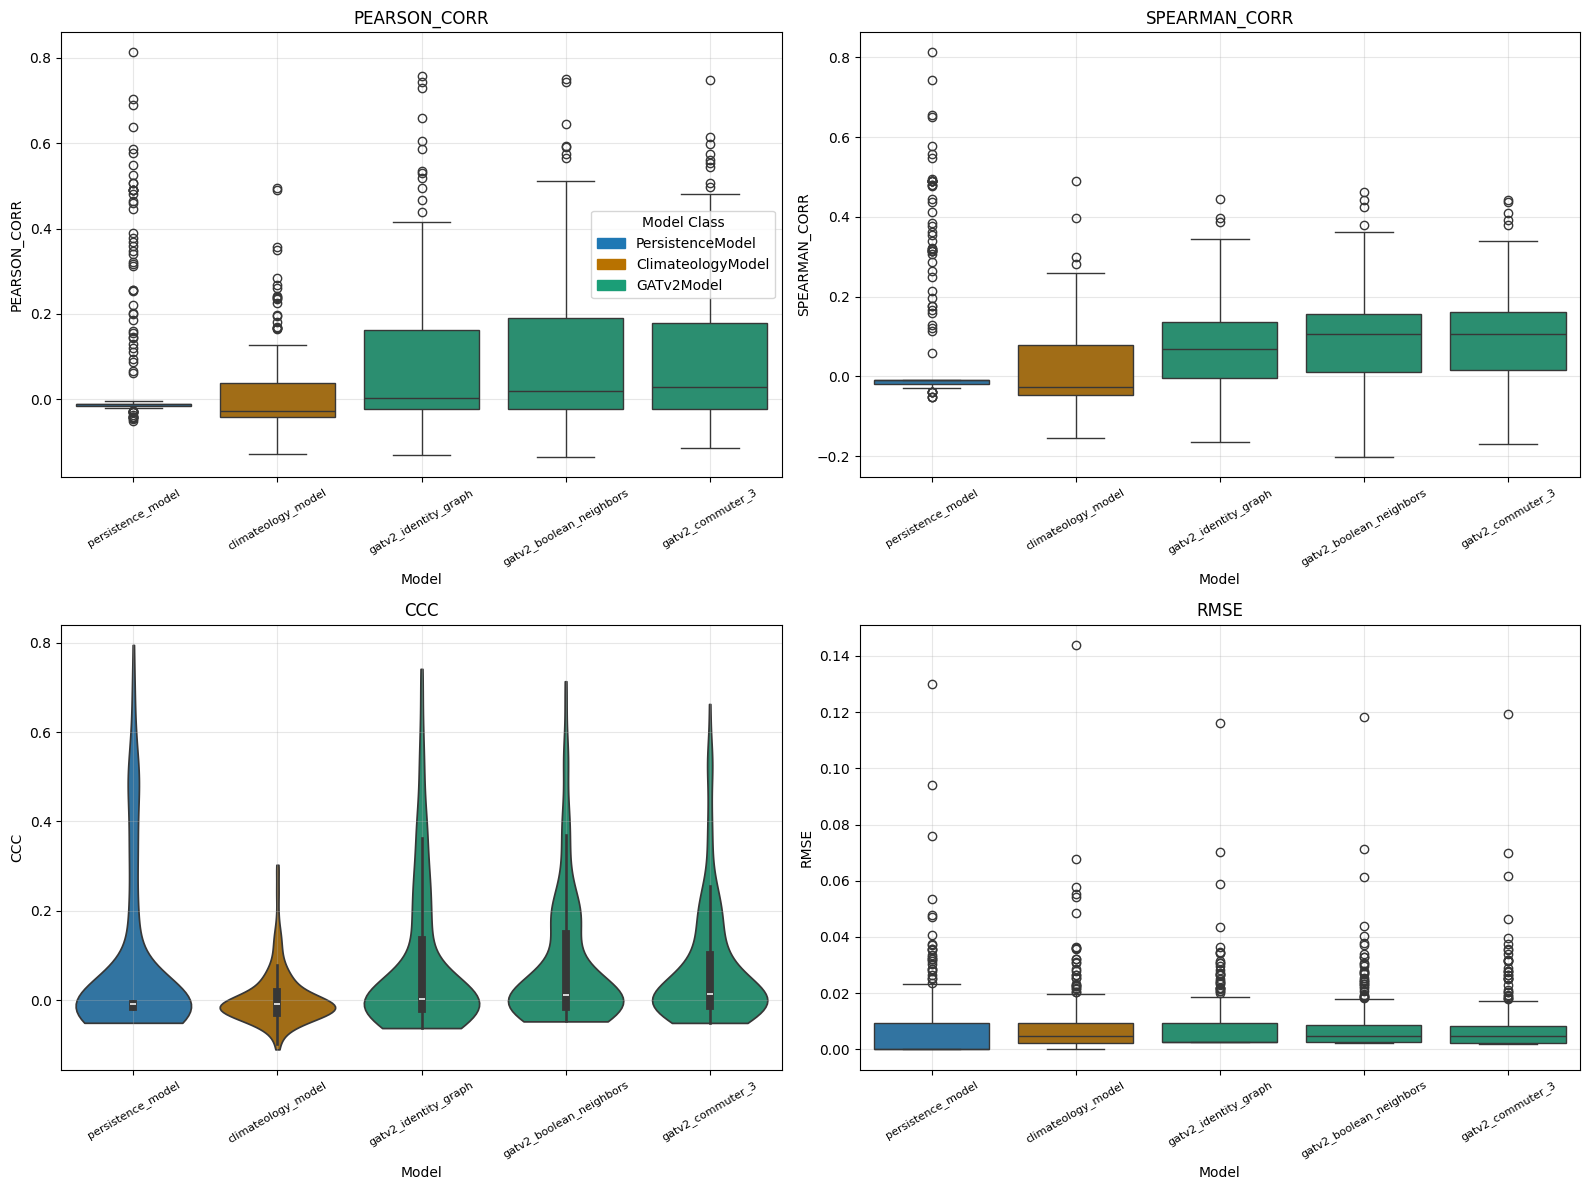

In [11]:
e.plotter.plot_metric_compilation().show()